## This notebook runs on one configuration (NOFLAG) and genertes the simulated data, It also estimates the power spectrum from the input data and plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]
# P_model = k_model**(-n)


k_fft = 2*np.pi*np.arange(N)/L

# kper = 0.1
# k_fft = np.sqrt( k_fft**2 + kper**2 ) 

k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont 
# P_dft = L * P_cont 
# P_dft = P_cont 

# binning 
NB = 64  # number of bins
NN_gp = 32
# NN_gp = 64
# NN_gp = 96
NN_gp = 112
# NN_gp = 128

In [3]:
(N**2 / L), (N / dL),  (N * dL),  (L), dL

(1130.082533147537,
 1130.0825331475373,
 521.9300207722049,
 521.9300207722049,
 0.6795963812138084)

In [4]:
# INP_SIGNAL_CONFIGS = {
#     "21cm": dict(type="21cm"),
#     "FG+21cm": dict(type="FG+21cm"),
#     "FG+MM+21cm": dict(type="FG+MM+21cm"),
# }
INP_SIGNAL_CONFIGS = {
    # "21cm": dict(type="21cm"),
    "FG+MM+21cm": dict(type="FG+MM+21cm"),
}

# # -----------------------------
# # FLAG configurations
# # -----------------------------
# FLAG_CONFIGS = {
#     "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
#     "RANDOM35": dict(mode="RANDOM", percent=35, seed=42),
#     "PERIODIC": dict(mode="PERIODIC", percent=0, seed=42),
#     "PERIODIC+RANDOM10": dict(mode="PERIODIC+RANDOM", percent=10, seed=42),
# }
FLAG_CONFIGS = {
    "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
}

# # -----------------------------
# # SCF configurations
# # -----------------------------
# SCF_CONFIGS = {
#     "None": dict(SCF="None", NN_gp=None, NN_hann=None),
#     "GP":   dict(SCF="GP",   NN_gp=96,  NN_hann=None),
#     "Hann": dict(SCF="Hann", NN_gp=None, NN_hann=50),
# }

SCF_CONFIGS = {
    "GP":   dict(SCF="GP",   NN_gp=NN_gp,  NN_hann=None),
}


In [5]:
def generate_fields(inp_signal, *, N, Nrea, P_dft):
    # 21-cm realizations (always needed)
    fields_21cm = np.array(
        [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
    )

    if inp_signal == "21cm":
        return fields_21cm

    if inp_signal == "FG+21cm":
        fields_forg = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e4,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )
        return fields_forg + fields_21cm

    if inp_signal == "FG+MM+21cm":
        fields_forg = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=100,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )
        return fields_forg + fields_21cm

    raise ValueError(f"Unknown inp_signal: {inp_signal}")


In [6]:
# fname = f"fft_inp_signal-{inp_signal}_flag-{flag}_SCF-{SCF}_NN-{NN_gp}.npz"
# fname

In [7]:
def run_one_configuration(
    fields_tota,
    inp_signal,
    flag_cfg,
    scf_cfg,
    *,
    N, L, dL, r, NB,
    k_model, P_model,
    P_cont, k_abs,
    path="results"
):
    # -----------------------------
    os.makedirs(path, exist_ok=True)
    # -----------------------------
    flag = pfunc.flagdata(
        N,
        mode=flag_cfg["mode"],
        percent=flag_cfg["percent"],
        seed=flag_cfg["seed"],
    )

    flag_percent = 100 * (1 - np.count_nonzero(flag) / N)
    print(
        f"[FLAG={flag_cfg['mode']}, SCF={scf_cfg['SCF']}] "
        f"flagged = {flag_percent:.1f}%"
    )

    # -----------------------------
    # SCF processing
    # -----------------------------
    fields_orig, fields_flag, ml = pfunc.process_scf(
        fields_tota,
        flag,
        scf_cfg["SCF"],
        NN_gp=scf_cfg["NN_gp"],
        NN_hann=scf_cfg["NN_hann"], verbose=True
    )
    
    # plt.plot(fields_orig[0])
    # plt.show()
    
    # -----------------------------
    # FFT estimator
    # -----------------------------
    pk_fft = pfunc.pk_fft(fields_flag, L, N)

    n1_fft, nend_fft = 0, N // 2
    kb_fft, mean_fft, err_fft, binned_th_fft, _ = pfunc.bin_power_spectrum(
        n1_fft, nend_fft,
        k_abs[n1_fft:nend_fft],
        pk_fft,
        P_cont,
        NB
    )

    # -----------------------------
    # DCT estimator
    # -----------------------------
    M = np.argmax(ml.real == 0) if np.any(ml.real == 0) else ml.shape[0]
    k_dct = np.pi * np.arange(M) / ((M - 1) * dL)
    # print(k_dct)
    
    P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)
    w = windows.nuttall(2*M)[M:]
    pk_dct, cl = pfunc.pk_dct(fields_flag, dL, ml, M, r, w)

    kb_dct, mean_dct, err_dct, binned_th_dct, _ = pfunc.bin_power_spectrum(
        0, M, k_dct, pk_dct, P_cont_dct, NB
    )

    # -----------------------------
    # Save outputs
    # -----------------------------
    flag_name = flag_cfg["mode"]
    SCF = scf_cfg["SCF"]

    # Construct filename matching your save_data style
    fields_fname = f"{path}/fields_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz"

    # Only save if the file does not exist
    # if not os.path.exists(fields_fname):
    # print(f"Saving fields to {fields_fname}...")
    np.savez(
        fields_fname,
        fields_tota=fields_tota,
        fields_orig=fields_orig,
        fields_flag=fields_flag,
        # Metadata (optional but helpful)
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF
    )

    pfunc.save_data(
        fname_prefix = f"{path}/fft",
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF,
        kb=kb_fft,
        mean=mean_fft,
        err=err_fft,
        binned_th=binned_th_fft,
        fname = f"{path}/fft_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz"
    )

    pfunc.save_data(
        fname_prefix = f"{path}/dct",
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF,
        kb=kb_dct,
        mean=mean_dct,
        err=err_dct,
        binned_th=binned_th_dct,
        fname = f"{path}/dct_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz"
    )

    np.savez(
        # f"{path}/CL_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}.npz",
        f"{path}/CL_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz",
        cl=cl,
        inp_signal=inp_signal,
        flag=flag,
        SCF=SCF,
    )



In [8]:
# # from tqdm.notebook import tqdm  # Use 'tqdm' if running in a script
# from tqdm import tqdm

# # Wrap your outer loop with tqdm
# for inp_signal in tqdm(INP_SIGNAL_CONFIGS, desc="Signals"):

#     print(f"\n=== Running inp_signal = {inp_signal} ===")
    
#     fields_tota = generate_fields(
#         inp_signal,
#         N=N, Nrea=Nrea, P_dft=P_dft,
#     )

    

#     # You can also wrap inner loops if they are long
#     for flag_key, flag_cfg in FLAG_CONFIGS.items():
#         for scf_key, scf_cfg in SCF_CONFIGS.items():
            
#             run_one_configuration(
#                 fields_tota=fields_tota,
#                 inp_signal=inp_signal,
#                 flag_cfg=flag_cfg,
#                 scf_cfg=scf_cfg,
#                 N=N, L=L, dL=dL, r=r, NB=NB,
#                 k_model=k_model,
#                 P_model=P_model,
#                 P_cont=P_cont,
#                 k_abs=k_abs,
#                 path="results_NN_gp",
#             )


In [9]:
import numpy as np

data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
summaries = data["summaries"]
amp_smooth = np.array([s["amp_smooth"] for s in summaries])
amp_fast   = np.array([s["amp_fast"] for s in summaries])
ell_fast   = np.array([s["ell_fast"] for s in summaries])
ell_ratio  = np.array([s["ell_fast_over_NN"] for s in summaries])
logL       = np.array([s["logL"] for s in summaries])
y_std      = np.array([s["y_std"] for s in summaries])
y_res_std  = np.array([s["y_res_std"] for s in summaries])
success    = np.array([s["success"] for s in summaries])

In [11]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- LOAD ----
# data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
# summaries = data["summaries"]

# # ---- EXTRACT ----
# A_S   = np.array([s["amp_smooth"] for s in summaries])
# y_std = np.array([s["y_std"] for s in summaries])

# # ---- CONVERT ----
# AS2   = A_S
# y_var = y_std**2

# # ---- STATS (original units) ----
# mean_AS2 = np.mean(AS2)
# std_AS2  = np.std(AS2)

# mean_yv  = np.mean(y_var)
# std_yv   = np.std(y_var)

# print(f"<A_S^2> = {mean_AS2:.4e}, std = {std_AS2:.4e}")
# print(f"<y_var> = {mean_yv:.4e}, std = {std_yv:.4e}")

# # ---- PLOT ----
# fig, ax = plt.subplots(figsize=(6,5))

# # scale ONLY for plotting
# AS2_plot = AS2 / 1e12
# y_var_plot = y_var / 1e12

# bins = np.linspace(AS2_plot.min(), AS2_plot.max(), 15)
# ax.hist(AS2_plot, bins=bins, histtype='step', linewidth=1.5)


# # bins = np.linspace(y_var_plot.min(), y_var_plot.max(), 15)
# # ax.hist(y_var_plot, bins=bins, histtype='step', linewidth=1.5)



# # mean lines (also scaled for plotting)
# ax.axvline(mean_AS2 / 1e12, linestyle='--', linewidth=1.5, color='C0',
#            label=rf"$\langle A_{{\mathrm S}}^2 \rangle = {mean_AS2:.2e}$"+r"$\, \mathrm{mK}^2$")

# ax.axvline(mean_yv / 1e12, linestyle=':', linewidth=2.0, color='k',
#            label=rf"$\langle \sigma_y^2 \rangle = {mean_yv:.2e}$"+r"$\, \mathrm{mK}^2$")

# # labels (as you want)
# ax.set_xlabel(r"$A_{\mathrm S}^2\ [10^{12}\ \mathrm{mK}^2]$")
# ax.set_ylabel(r"${\rm Count}$")

# # legend
# ax.legend()

# # ---- SAVE ----
# plt.tight_layout()
# plt.savefig(f"gpfit/AS2_scaled_vs_yvar_NN_{NN_gp}.pdf")

# plt.show()

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- SCALE FACTOR ----
# scale = 1e3   # change this as needed

# # ---- LOAD ----
# data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
# summaries = data["summaries"]

# # ---- EXTRACT ----
# A_F       = np.array([s["amp_fast"] for s in summaries])
# y_res_std = np.array([s["y_res_std"] for s in summaries])

# # ---- CONVERT ----
# AF2       = A_F
# y_res_var = y_res_std**2


# AF2       = AF2/y_res_var * y_var

# # ---- STATS (original units) ----
# mean_AF2 = np.mean(AF2)
# std_AF2  = np.std(AF2)

# mean_yres = np.mean(y_res_var)
# std_yres  = np.std(y_res_var)

# print(f"<A_F^2> = {mean_AF2:.4e}, std = {std_AF2:.4e}")
# print(f"<y_res_var> = {mean_yres:.4e}, std = {std_yres:.4e}")

# # ---- PLOT ----
# fig, ax = plt.subplots(figsize=(6,5))

# # scale ONLY for plotting
# AF2_plot   = AF2 / scale
# y_res_plot = y_res_var / scale

# bins = np.linspace(AF2_plot.min(), AF2_plot.max(), 15)
# ax.hist(AF2_plot, bins=bins, histtype='step', linewidth=1.5)

# # mean lines (scaled for plotting)
# ax.axvline(mean_AF2 / scale, linestyle='--', linewidth=1.5, color='C1',
#            label=rf"$\langle A_{{\mathrm R}}^2 \rangle = {mean_AF2:.2e}$"+r"$\, \mathrm{mK}^2$")

# ax.axvline(mean_yres / scale, linestyle=':', linewidth=2.0, color='k',
#            label=rf"$\langle \sigma_{{\mathrm res}}^2 \rangle = {mean_yres:.2e}$"+r"$\, \mathrm{mK}^2$")

# # labels (dynamic scale in label)
# # ax.set_xlabel(rf"$A_{{\mathrm F}}^2\ [{scale:.0e}\ \mathrm{{mK}}^2]$")
# ax.set_xlabel(r"$A_{\mathrm R}^2\ [10^{3}\ \mathrm{mK}^2]$")
# ax.set_ylabel(r"${\rm Count}$")
# # ax.set_xscale('log')

# # legend
# ax.legend()

# # ---- SAVE ----
# plt.tight_layout()
# plt.savefig(f"gpfit/AF2_scaled_vs_yresvar_NN_{NN_gp}.pdf")

# plt.show()

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- SCALE FACTOR ----
# scale = 1   # change if you want to rescale ell (e.g., channel units)

# # ---- LOAD ----
# data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
# summaries = data["summaries"]

# # ---- EXTRACT ----
# ell_fast = np.array([s["ell_fast"] for s in summaries])*dnuc

# # ---- STATS ----
# mean_ell = np.mean(ell_fast)
# std_ell  = np.std(ell_fast)

# print(f"<ell_fast> = {mean_ell:.4e}, std = {std_ell:.4e}")

# # ---- PLOT ----
# fig, ax = plt.subplots(figsize=(6,5))

# # scale ONLY for plotting
# ell_plot = ell_fast / scale

# bins = np.linspace(ell_plot.min(), ell_plot.max(), 15)
# ax.hist(ell_plot, bins=bins, histtype='step', linewidth=1.5)

# # mean line
# ax.axvline(mean_ell / scale, linestyle='--', linewidth=1.5,
#            label=rf"$\langle N_{{\mathrm{{R}}}} \rangle = {mean_ell:.2f} \ \mathrm{{MHz}}$")

# # labels
# ax.set_xlabel(rf"$N_{{\mathrm{{R}}}} \ \mathrm{{MHz}}$")
# ax.set_ylabel(r"${\rm Count}$")

# # legend
# ax.legend()

# # ---- SAVE ----
# plt.tight_layout()
# plt.savefig(f"gpfit/ell_fast_distribution_NN_{NN_gp}.pdf")

# plt.show()

In [14]:
# Plot

In [15]:
def FGname(inp_signal):
    if (inp_signal == '21cm'):
        FG = 'None'
        dataname = '21cm'
    elif (inp_signal == 'FG+21cm'):
        FG = 'Smooth'
        dataname = 'FG'
    elif (inp_signal == 'FG+MM+21cm'):
        FG = 'Unsmooth'
        dataname = 'FGMM'
    return FG, dataname

inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
Saved: plots/FGMM_GP_allflags.pdf


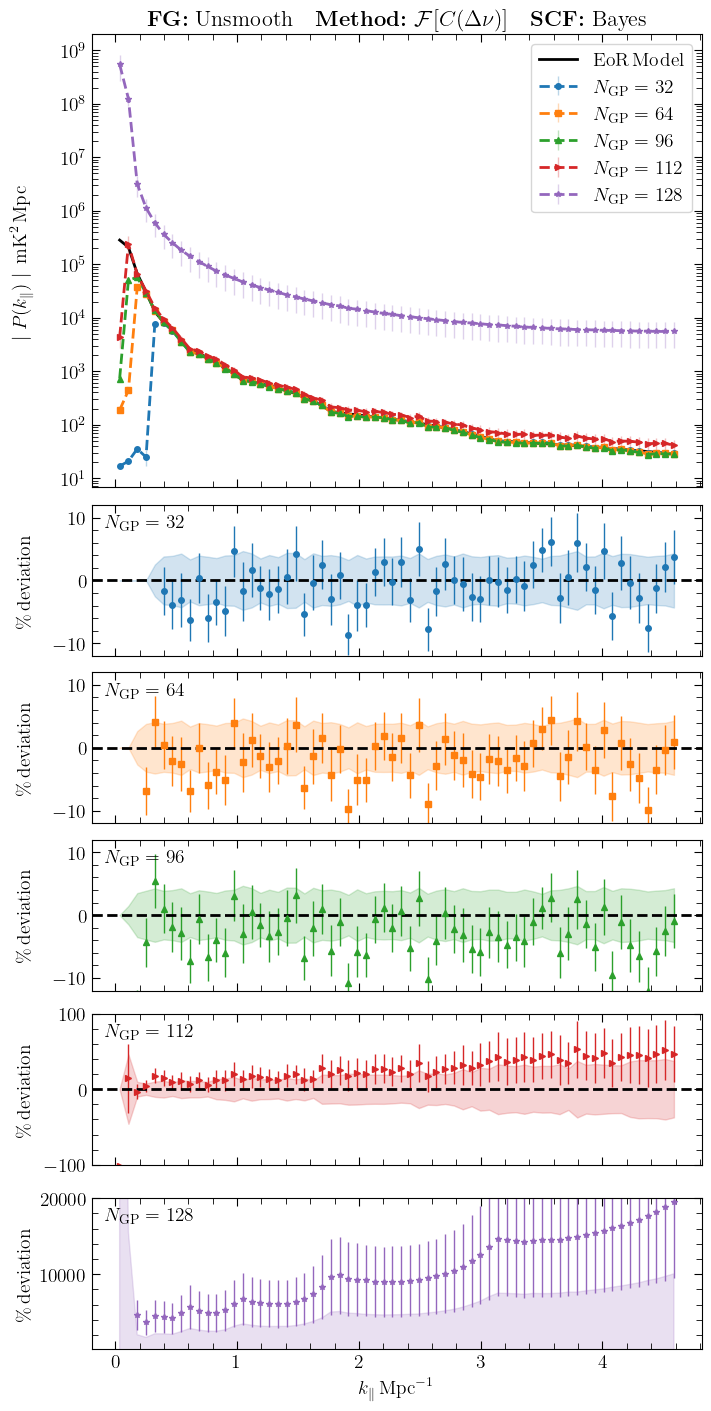

In [16]:
inp_signal = "21cm"
inp_signal = "FG+MM+21cm"
SCF        = "GP"
path       = "results_NN_gp"
modes  = ['NOFLAG']
# colors = ['C1']
# fmts = ['s']


modes  = [32, 64, 96, 112, 128]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
fmts = ['o', 's', '^', '>', '*']


FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210
shift, ylim = 1.0, 12
 
figname = f"plots/{dataname}_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 14))
gs  = fig.add_gridspec(
    6, 1,
    height_ratios=[3, 1, 1, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 6)]


# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-NOFLAG_SCF-GP_NN-{mode}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$N_{{\rm GP}} = \rm{{ {mode} }}$" 

    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')
    # axd[i].set_xscale('log')

    axd[i].text(
        0.02, 0.85,
        fr"$N_{{\rm GP}} = \rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)
    axd[-1].set_ylim(1e2, 2e4)
    axd[-2].set_ylim(-1e2, 1e2)

    
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel) \mid \,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

SCF = 'Bayes'
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


In [17]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- CHOOSE ALL NN_gp VALUES ----
# NN_list = [32, 64, 96, 112, 128]   # <-- modify as needed

# all_AS2 = []

# # ---- LOAD ALL DATA FIRST (for consistent bins) ----
# for NN_gp in NN_list:
#     data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
#     summaries = data["summaries"]

#     A_S = np.array([s["amp_smooth"] for s in summaries])
#     AS2 = A_S  # already squared in your convention

#     all_AS2.append(AS2 / 1e12)  # scale only for plotting

# # ---- GLOBAL BINS ----
# all_vals = np.concatenate(all_AS2)
# bins = np.linspace(all_vals.min(), all_vals.max(), 20)

# # ---- PLOT ----
# fig, ax = plt.subplots(figsize=(6,5))

# for NN_gp, AS2_plot in zip(NN_list, all_AS2):
#     ax.hist(AS2_plot, bins=bins, histtype='step', linewidth=1.5,
#             label=rf"$N_{{\rm GP}} = {NN_gp}$")

# # ---- LABELS ----
# ax.set_xlabel(r"$A_{\mathrm S}^2\ [10^{12}\ \mathrm{mK}^2]$")
# ax.set_ylabel(r"${\rm Count}$")
# ax.set_xscale('log')

# # ---- LEGEND ----
# ax.legend()

# # ---- SAVE ----
# plt.tight_layout()
# plt.savefig("gpfit/AS2_all_NN_comparison.pdf")

# plt.show()

In [18]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- SCALE FACTOR ----
# scale = 1e3

# # ---- NN list ----

# all_AF2 = []

# # ---- LOAD ALL DATA FIRST ----
# for NN_gp in NN_list:
#     data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
#     summaries = data["summaries"]

#     # ---- EXTRACT ----
#     A_F       = np.array([s["amp_fast"] for s in summaries])
#     y_res_std = np.array([s["y_res_std"] for s in summaries])
#     y_std     = np.array([s["y_std"] for s in summaries])   # <-- needed

#     # ---- CONVERT ----
#     y_res_var = y_res_std**2
#     y_var     = y_std**2

#     AF2 = A_F
#     AF2 = AF2 / y_res_var * y_var   # your rescaling

#     all_AF2.append(AF2 / scale)

# # ---- GLOBAL BINS ----
# all_vals = np.concatenate(all_AF2)
# bins = np.linspace(all_vals.min(), all_vals.max(), 20)

# # ---- PLOT ----
# fig, ax = plt.subplots(figsize=(6,5))

# for NN_gp, AF2_plot in zip(NN_list, all_AF2):
#     ax.hist(AF2_plot, bins=bins, histtype='step', linewidth=1.5,
#             label=rf"$N_{{\rm GP}} = {NN_gp}$")

# # ---- LABELS ----
# ax.set_xlabel(r"$A_{\mathrm R}^2\ [10^{3}\ \mathrm{mK}^2]$")
# ax.set_ylabel(r"${\rm Count}$")

# # ---- LEGEND ----
# ax.legend()

# # ---- SAVE ----
# plt.tight_layout()
# plt.savefig("gpfit/AF2_all_NN_comparison.pdf")

# plt.show()

In [19]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- SCALE FACTOR ----
# scale = 1   # keep if you want flexibility later

# # ---- CHOOSE NN_gp VALUES ----

# all_ell = []

# # ---- LOAD ALL FIRST (for consistent bins) ----
# for NN_gp in NN_list:
#     data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
#     summaries = data["summaries"]

#     ell_fast = np.array([s["ell_fast"] for s in summaries]) * dnuc
#     all_ell.append(ell_fast / scale)

# # ---- GLOBAL BINS ----
# all_vals = np.concatenate(all_ell)
# bins = np.linspace(all_vals.min(), all_vals.max(), 20)

# # ---- PLOT ----
# fig, ax = plt.subplots(figsize=(6,5))

# for NN_gp, ell_plot in zip(NN_list, all_ell):
#     ax.hist(ell_plot, bins=bins, histtype='step', linewidth=1.5,
#             label=rf"$N_{{\rm GP}} = {NN_gp}$")

# # ---- LABELS ----
# ax.set_xlabel(r"$N_{\mathrm{R}}\ \mathrm{[MHz]}$")
# ax.set_ylabel(r"${\rm Count}$")

# # ---- LEGEND ----
# ax.legend()

# # ---- SAVE ----
# plt.tight_layout()
# plt.savefig("gpfit/ell_fast_all_NN_comparison.pdf")

# plt.show()

In [20]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- NN list ----
# NN_list = [32, 64, 96, 112, 128]
# nN = len(NN_list)

# # ---- SCALE FACTORS ----
# scale_AS2 = 1e12
# scale_AF2 = 1e3
# scale_ell = 1

# # ---- FIGURE ----
# fig, axes = plt.subplots(3, nN, figsize=(4*nN, 14), sharey=False)

# for j, NN_gp in enumerate(NN_list):

#     # ---- LOAD ----
#     data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
#     summaries = data["summaries"]

#     # =========================
#     # 1. A_S^2 (smooth amp)
#     # =========================
#     A_S = np.array([s["amp_smooth"] for s in summaries])
#     AS2 = A_S / scale_AS2

#     bins = np.linspace(AS2.min(), AS2.max(), 15)
#     axes[0, j].hist(AS2, bins=bins, histtype='step', linewidth=1.5)

#     axes[0, j].set_title(rf"$N_{{\rm GP}}={NN_gp}$")
#     if j == 0:
#         axes[0, j].set_ylabel("Count")

#     # axes[0, j].set_xscale('log')


#     # =========================
#     # 2. A_F^2 (fast amp rescaled)
#     # =========================
#     A_F       = np.array([s["amp_fast"] for s in summaries])
#     y_res_std = np.array([s["y_res_std"] for s in summaries])
#     y_std     = np.array([s["y_std"] for s in summaries])

#     y_res_var = y_res_std**2
#     y_var     = y_std**2

#     AF2 = (A_F / y_res_var) * y_var
#     AF2 = AF2 / scale_AF2

#     bins = np.linspace(AF2.min(), AF2.max(), 15)
#     axes[1, j].hist(AF2, bins=bins, histtype='step', linewidth=1.5)

#     if j == 0:
#         axes[1, j].set_ylabel("Count")


#     # =========================
#     # 3. ell_fast
#     # =========================
#     ell_fast = np.array([s["ell_fast"] for s in summaries]) * dnuc
#     ell_plot = ell_fast / scale_ell

#     bins = np.linspace(ell_plot.min(), ell_plot.max(), 15)
#     axes[2, j].hist(ell_plot, bins=bins, histtype='step', linewidth=1.5)

#     if j == 0:
#         axes[2, j].set_ylabel("Count")


# # ---- X LABELS (bottom row only) ----
# for j in range(nN):
#     axes[2, j].set_xlabel(r"$N_{\mathrm{R}}\ \mathrm{[MHz]}$")
#     axes[1, j].set_xlabel(r"$A_{\mathrm R}^2\ [10^{3}\ \mathrm{mK}^2]$")
#     axes[0, j].set_xlabel(r"$A_{\mathrm S}^2\ [10^{12}\ \mathrm{mK}^2]$")

# # ---- LAYOUT ----
# plt.tight_layout()
# plt.savefig("gpfit/hyperparameter_grid_all_NN.pdf")
# plt.show()

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_4127/1259138333.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


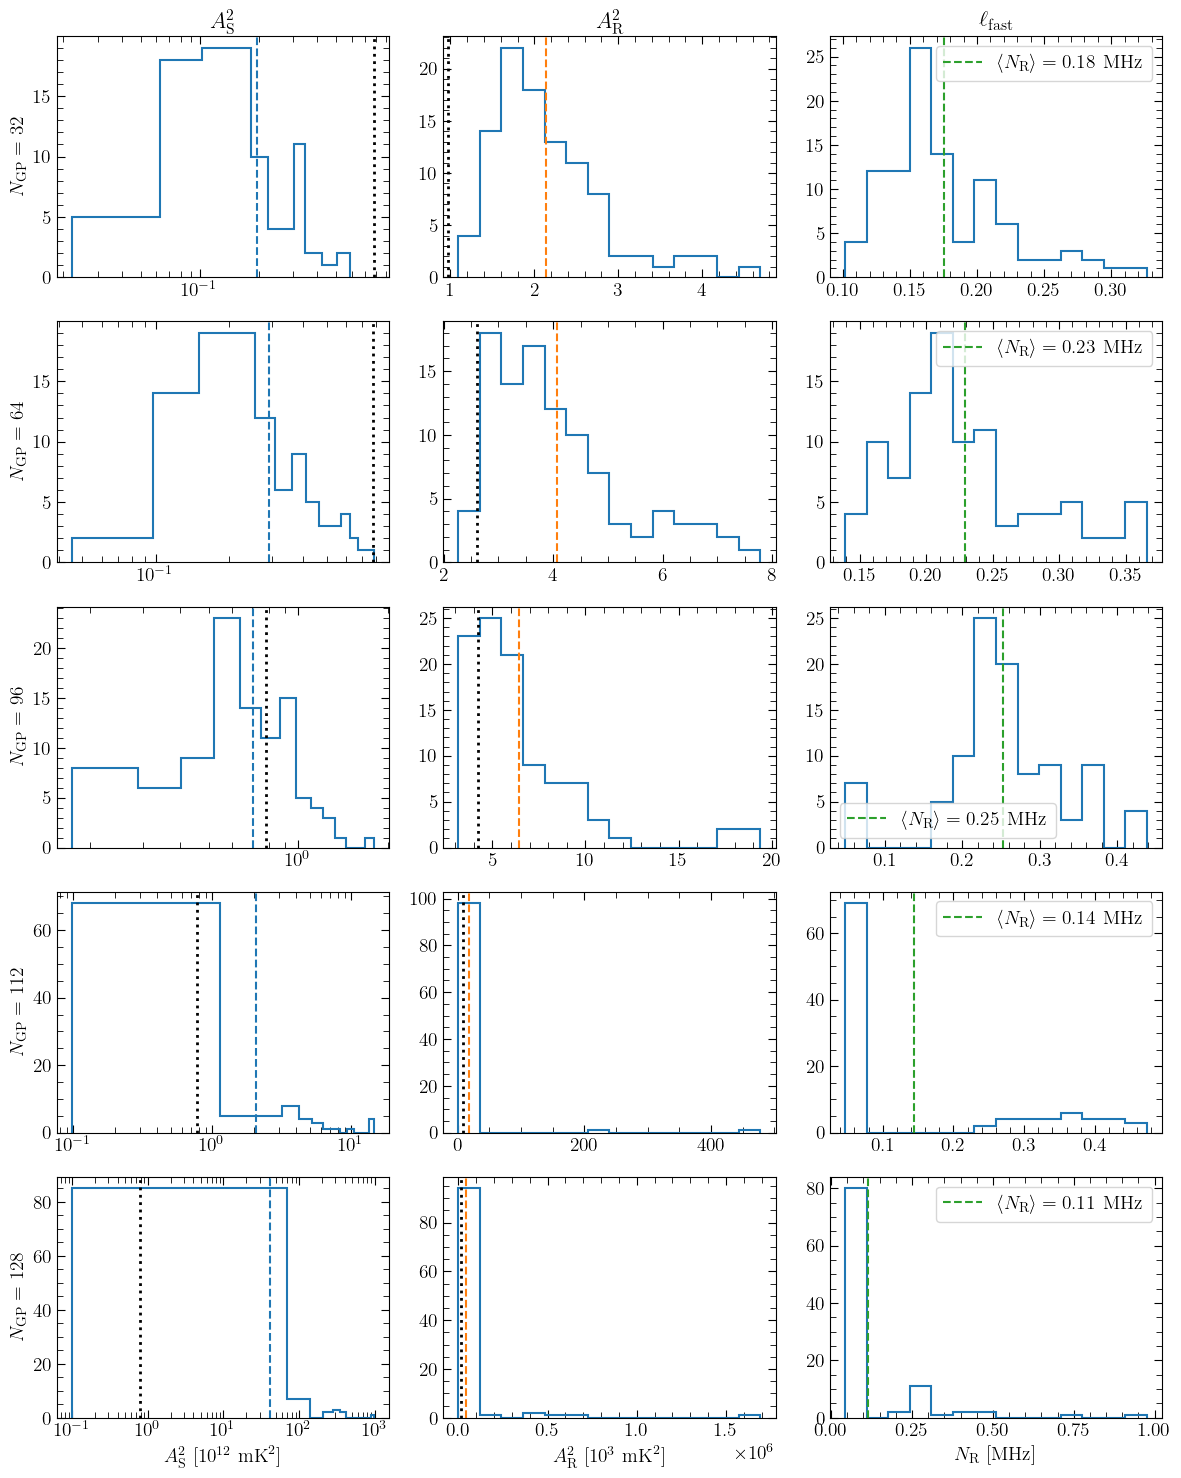

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ---- NN list ----
NN_list = [32, 64, 96, 112, 128]
nN = len(NN_list)

# ---- SCALE FACTORS ----
scale_AS2 = 1e12
scale_AF2 = 1e3
scale_ell = 1

# ---- FIGURE: rows = NN, cols = params ----
fig, axes = plt.subplots(nN, 3, figsize=(12, 3*nN), sharey=False)

for i, NN_gp in enumerate(NN_list):

    data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
    summaries = data["summaries"]

    # =========================
    # Column 0: A_S^2
    # =========================
    A_S   = np.array([s["amp_smooth"] for s in summaries])
    y_std = np.array([s["y_std"] for s in summaries])

    AS2   = A_S
    y_var = y_std**2

    mean_AS2 = np.mean(AS2)
    mean_yv  = np.mean(y_var)

    AS2_plot   = AS2 / scale_AS2
    y_var_plot = y_var / scale_AS2

    ax = axes[i, 0]
    bins = np.linspace(AS2_plot.min(), AS2_plot.max(), 15)
    ax.hist(AS2_plot, bins=bins, histtype='step', linewidth=1.5)

    ax.axvline(mean_AS2 / scale_AS2, linestyle='--', linewidth=1.5, color='C0')
    ax.axvline(mean_yv  / scale_AS2, linestyle=':',  linewidth=2.0, color='k')

    ax.set_xscale('log')
    if i == 0:
        ax.set_title(r"$A_{\mathrm S}^2$")
    ax.set_ylabel(rf"$N_{{\rm GP}}={NN_gp}$")


    # =========================
    # Column 1: A_F^2
    # =========================
    A_F       = np.array([s["amp_fast"] for s in summaries])
    y_res_std = np.array([s["y_res_std"] for s in summaries])

    y_res_var = y_res_std**2

    AF2 = (A_F / y_res_var) * y_var

    mean_AF2  = np.mean(AF2)
    mean_yres = np.mean(y_res_var)

    AF2_plot   = AF2 / scale_AF2
    y_res_plot = y_res_var / scale_AF2

    ax = axes[i, 1]
    bins = np.linspace(AF2_plot.min(), AF2_plot.max(), 15)
    ax.hist(AF2_plot, bins=bins, histtype='step', linewidth=1.5)

    ax.axvline(mean_AF2  / scale_AF2, linestyle='--', linewidth=1.5, color='C1')
    ax.axvline(mean_yres / scale_AF2, linestyle=':',  linewidth=2.0, color='k')

    if i == 0:
        ax.set_title(r"$A_{\mathrm R}^2$")


    # =========================
    # Column 2: ell_fast
    # =========================
    ell_fast = np.array([s["ell_fast"] for s in summaries]) * dnuc
    mean_ell = np.mean(ell_fast)

    ell_plot = ell_fast / scale_ell

    ax = axes[i, 2]
    bins = np.linspace(ell_plot.min(), ell_plot.max(), 15)
    ax.hist(ell_plot, bins=bins, histtype='step', linewidth=1.5)

    ax.axvline(mean_ell / scale_ell, linestyle='--', linewidth=1.5, color='C2',
               label=rf"$\langle N_{{\mathrm{{R}}}} \rangle = {mean_ell:.2f} \ \mathrm{{MHz}}$")

    if i == 0:
        ax.set_title(r"$\ell_{\mathrm{fast}}$")
    ax.legend()


# ---- X LABELS (bottom row only) ----
axes[-1, 0].set_xlabel(r"$A_{\mathrm S}^2\ [10^{12}\ \mathrm{mK}^2]$")
axes[-1, 1].set_xlabel(r"$A_{\mathrm R}^2\ [10^{3}\ \mathrm{mK}^2]$")
axes[-1, 2].set_xlabel(r"$N_{\mathrm{R}}\ \mathrm{[MHz]}$")

plt.tight_layout()
plt.savefig("gpfit/hyperparameter_grid_transposed.pdf")
plt.show()

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_4127/322295022.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


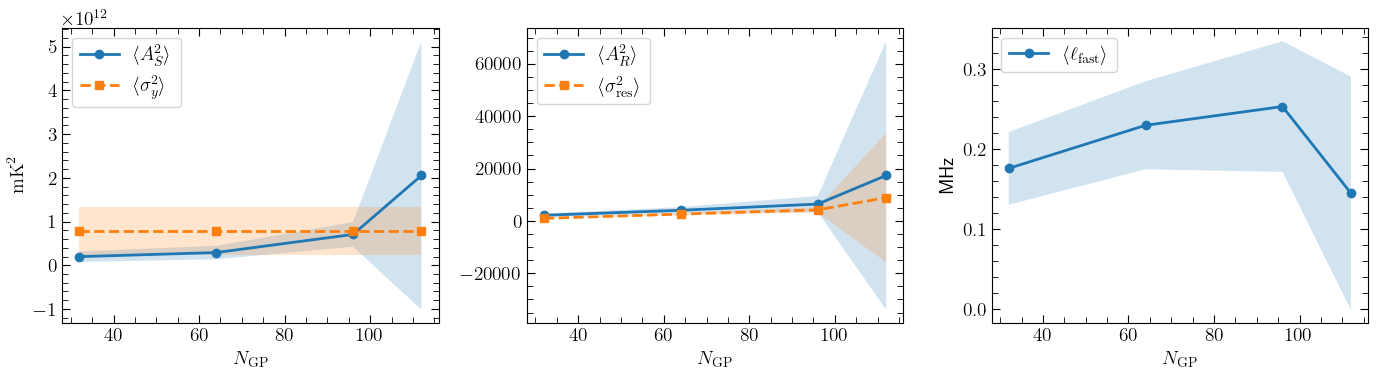

In [22]:
import numpy as np
import matplotlib.pyplot as plt

NN_list = [32, 64, 96, 112, 128]
NN_list = [32, 64, 96, 112]

mean_AS2_list, std_AS2_list = [], []
mean_yv_list,  std_yv_list  = [], []

mean_AF2_list,  std_AF2_list  = [], []
mean_yres_list, std_yres_list = [], []

mean_ell_list, std_ell_list = [], []

for NN_gp in NN_list:

    data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
    summaries = data["summaries"]

    # ---- extract ----
    A_S       = np.array([s["amp_smooth"] for s in summaries])
    y_std     = np.array([s["y_std"] for s in summaries])
    A_F       = np.array([s["amp_fast"] for s in summaries])
    y_res_std = np.array([s["y_res_std"] for s in summaries])
    ell_fast  = np.array([s["ell_fast"] for s in summaries]) * dnuc

    y_var     = y_std**2
    y_res_var = y_res_std**2
    AF2       = (A_F / y_res_var) * y_var

    # ---- store mean + std ----
    mean_AS2_list.append(np.mean(A_S))
    std_AS2_list.append(np.std(A_S))

    mean_yv_list.append(np.mean(y_var))
    std_yv_list.append(np.std(y_var))

    mean_AF2_list.append(np.mean(AF2))
    std_AF2_list.append(np.std(AF2))

    mean_yres_list.append(np.mean(y_res_var))
    std_yres_list.append(np.std(y_res_var))

    mean_ell_list.append(np.mean(ell_fast))
    std_ell_list.append(np.std(ell_fast))


# convert to arrays
mean_AS2 = np.array(mean_AS2_list)
std_AS2  = np.array(std_AS2_list)

mean_yv = np.array(mean_yv_list)
std_yv  = np.array(std_yv_list)

mean_AF2 = np.array(mean_AF2_list)
std_AF2  = np.array(std_AF2_list)

mean_yres = np.array(mean_yres_list)
std_yres  = np.array(std_yres_list)

mean_ell = np.array(mean_ell_list)
std_ell  = np.array(std_ell_list)


# ---- PLOT ----
fig, ax = plt.subplots(1, 3, figsize=(14,4))

# =====================
# A_S^2
# =====================
ax[0].plot(NN_list, mean_AS2, 'o-', label=r"$\langle A_S^2 \rangle$")
ax[0].fill_between(NN_list, mean_AS2-std_AS2, mean_AS2+std_AS2, alpha=0.2)

ax[0].plot(NN_list, mean_yv, 's--', label=r"$\langle \sigma_y^2 \rangle$")
ax[0].fill_between(NN_list, mean_yv-std_yv, mean_yv+std_yv, alpha=0.2)

ax[0].set_xlabel(r"$N_{\rm GP}$")
ax[0].set_ylabel(r"$\mathrm{mK}^2$")
ax[0].legend()


# =====================
# A_R^2
# =====================
ax[1].plot(NN_list, mean_AF2, 'o-', label=r"$\langle A_R^2 \rangle$")
ax[1].fill_between(NN_list, mean_AF2-std_AF2, mean_AF2+std_AF2, alpha=0.2)

ax[1].plot(NN_list, mean_yres, 's--', label=r"$\langle \sigma_{\rm res}^2 \rangle$")
ax[1].fill_between(NN_list, mean_yres-std_yres, mean_yres+std_yres, alpha=0.2)

ax[1].set_xlabel(r"$N_{\rm GP}$")
ax[1].legend()


# =====================
# ell
# =====================
ax[2].plot(NN_list, mean_ell, 'o-', label=r"$\langle \ell_{\rm fast} \rangle$")
ax[2].fill_between(NN_list, mean_ell-std_ell, mean_ell+std_ell, alpha=0.2)

ax[2].set_xlabel(r"$N_{\rm GP}$")
ax[2].set_ylabel("MHz")
ax[2].legend()


plt.tight_layout()
plt.savefig("gpfit/hyperparameter_summary_with_std.pdf")
plt.show()

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_4127/1266214838.py:118: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


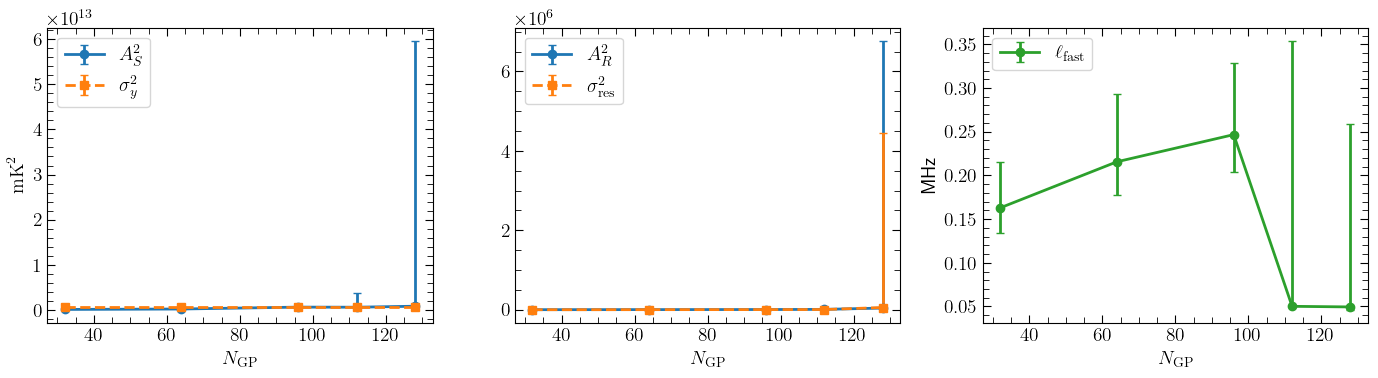

In [23]:
import numpy as np
import matplotlib.pyplot as plt

NN_list = [32, 64, 96, 112, 128]

# storage
med_AS2, lo_AS2, hi_AS2 = [], [], []
med_yv,  lo_yv,  hi_yv  = [], [], []

med_AF2,  lo_AF2,  hi_AF2  = [], [], []
med_yres, lo_yres, hi_yres = [], [], []

med_ell, lo_ell, hi_ell = [], [], []

for NN_gp in NN_list:

    data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
    summaries = data["summaries"]

    # ---- extract ----
    A_S       = np.array([s["amp_smooth"] for s in summaries])
    y_std     = np.array([s["y_std"] for s in summaries])
    A_F       = np.array([s["amp_fast"] for s in summaries])
    y_res_std = np.array([s["y_res_std"] for s in summaries])
    ell_fast  = np.array([s["ell_fast"] for s in summaries]) * dnuc

    y_var     = y_std**2
    y_res_var = y_res_std**2
    AF2       = (A_F / y_res_var) * y_var

    # ---- percentiles ----
    def p16_50_84(x):
        return np.percentile(x, [16, 50, 84])

    # A_S^2
    p16, p50, p84 = p16_50_84(A_S)
    lo_AS2.append(p50 - p16)
    hi_AS2.append(p84 - p50)
    med_AS2.append(p50)

    # y_var
    p16, p50, p84 = p16_50_84(y_var)
    lo_yv.append(p50 - p16)
    hi_yv.append(p84 - p50)
    med_yv.append(p50)

    # A_F^2
    p16, p50, p84 = p16_50_84(AF2)
    lo_AF2.append(p50 - p16)
    hi_AF2.append(p84 - p50)
    med_AF2.append(p50)

    # y_res_var
    p16, p50, p84 = p16_50_84(y_res_var)
    lo_yres.append(p50 - p16)
    hi_yres.append(p84 - p50)
    med_yres.append(p50)

    # ell
    p16, p50, p84 = p16_50_84(ell_fast)
    lo_ell.append(p50 - p16)
    hi_ell.append(p84 - p50)
    med_ell.append(p50)


# convert to arrays
med_AS2, lo_AS2, hi_AS2 = map(np.array, (med_AS2, lo_AS2, hi_AS2))
med_yv,  lo_yv,  hi_yv  = map(np.array, (med_yv,  lo_yv,  hi_yv))

med_AF2,  lo_AF2,  hi_AF2  = map(np.array, (med_AF2,  lo_AF2,  hi_AF2))
med_yres, lo_yres, hi_yres = map(np.array, (med_yres, lo_yres, hi_yres))

med_ell, lo_ell, hi_ell = map(np.array, (med_ell, lo_ell, hi_ell))


# ---- PLOT ----
fig, ax = plt.subplots(1, 3, figsize=(14,4))

# =====================
# A_S^2
# =====================
ax[0].errorbar(NN_list, med_AS2, yerr=[lo_AS2, hi_AS2],
               fmt='o-', capsize=3, label=r"$A_S^2$")

ax[0].errorbar(NN_list, med_yv, yerr=[lo_yv, hi_yv],
               fmt='s--', capsize=3, label=r"$\sigma_y^2$")

ax[0].set_xlabel(r"$N_{\rm GP}$")
ax[0].set_ylabel(r"$\mathrm{mK}^2$")
ax[0].legend()


# =====================
# A_R^2
# =====================
ax[1].errorbar(NN_list, med_AF2, yerr=[lo_AF2, hi_AF2],
               fmt='o-', capsize=3, label=r"$A_R^2$")

ax[1].errorbar(NN_list, med_yres, yerr=[lo_yres, hi_yres],
               fmt='s--', capsize=3, label=r"$\sigma_{\rm res}^2$")

ax[1].set_xlabel(r"$N_{\rm GP}$")
ax[1].legend()


# =====================
# ell
# =====================
ax[2].errorbar(NN_list, med_ell, yerr=[lo_ell, hi_ell],
               fmt='o-', capsize=3, color='C2',
               label=r"$\ell_{\rm fast}$")

ax[2].set_xlabel(r"$N_{\rm GP}$")
ax[2].set_ylabel("MHz")
ax[2].legend()


plt.tight_layout()
plt.savefig("gpfit/hyperparameter_summary_percentiles.pdf")
plt.show()

In [24]:
def fmt(val, lo, hi, scale=1):
    v = val / scale
    l = lo  / scale
    h = hi  / scale
    return rf"${v:.2f}_{{-{l:.2f}}}^{{+{h:.2f}}}$"
    
scale_AS2  = 1e11
scale_AF2  = 1e3
scale_yres = 1e3

# representative value for caption (since it's constant)
sigma_y_med = np.median(med_yv)

print(r"\begin{table*}")
print(r"\centering")

# spacing
print(r"\renewcommand{\arraystretch}{1.4}")
print(r"\setlength{\tabcolsep}{8pt}")

print(rf"\caption{{GP hyperparameter summary (median with 16--84\% intervals). "
      rf"$\sigma_y^2 = {sigma_y_med/scale_AS2:.2f}\times 10^{{11}}\ \mathrm{{mK}}^2$ "
      rf"(approximately constant across $N_{{\rm GP}}$).}}")

print(r"\begin{tabular}{c c c c}")
print(r"\hline")
print(r"$N_{\rm GP}$ & $A_S^2\ [10^{11}\ \mathrm{mK}^2]$ & $A_R^2\ [10^{3}\ \mathrm{mK}^2]$ & $\ell_{\rm fast}\ (\mathrm{MHz})$ \\")
print(r"\hline")

for i, NN in enumerate(NN_list):
    row = (
        f"{NN} & "
        f"{fmt(med_AS2[i], lo_AS2[i], hi_AS2[i], scale_AS2)} & "
        f"{fmt(med_AF2[i], lo_AF2[i], hi_AF2[i], scale_AF2)} & "
        f"{fmt(med_ell[i], lo_ell[i], hi_ell[i])} \\\\"
    )
    print(row)

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table*}")

\begin{table*}
\centering
\renewcommand{\arraystretch}{1.4}
\setlength{\tabcolsep}{8pt}
\caption{GP hyperparameter summary (median with 16--84\% intervals). $\sigma_y^2 = 5.98\times 10^{11}\ \mathrm{mK}^2$ (approximately constant across $N_{\rm GP}$).}
\begin{tabular}{c c c c}
\hline
$N_{\rm GP}$ & $A_S^2\ [10^{11}\ \mathrm{mK}^2]$ & $A_R^2\ [10^{3}\ \mathrm{mK}^2]$ & $\ell_{\rm fast}\ (\mathrm{MHz})$ \\
\hline
32 & $1.57_{-0.62}^{+1.64}$ & $1.94_{-0.37}^{+0.74}$ & $0.16_{-0.03}^{+0.05}$ \\
64 & $2.51_{-0.99}^{+1.80}$ & $3.76_{-0.86}^{+1.58}$ & $0.22_{-0.04}^{+0.08}$ \\
96 & $6.70_{-2.36}^{+2.93}$ & $5.68_{-1.67}^{+2.81}$ & $0.25_{-0.04}^{+0.08}$ \\
112 & $6.48_{-2.57}^{+32.38}$ & $9.66_{-4.42}^{+6.94}$ & $0.05_{-0.00}^{+0.30}$ \\
128 & $8.70_{-4.33}^{+586.31}$ & $42.55_{-34.77}^{+6718.75}$ & $0.05_{-0.00}^{+0.21}$ \\
\hline
\end{tabular}
\end{table*}
